# Imports

In [10]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt
from matplotlib.pylab import sqrt
import scipy
from scipy.stats import genextreme
import plotly.express as px
import torch
import torch.nn as nn

# Variables

In [11]:
# C, material const., calibrated experimentally
# set values to calibrate C
stress_amp = 100        # stress amplitude
defect_size = 100       # defect size
N_target = 1e5          # target N for these values        
m = 2.7                 # sensitivity to stress
n = 1.5                 # sensitivity to defect size, = nn.Parameter(torch.tensor(1.5))

# calibrate C given these values
C = N_target * (stress_amp**m) * (defect_size**n)

In [12]:
# define constants
mu = 3              # mean of log
sigma = 1           # std dev of log
Y = 1.0             # geometry factor

# define variables
n_defects = 1000    # size of random dataset
defect_size = np.linspace(start=20, stop=600, num=n_defects)     # surface area of defect, A, [mm^2]
stress_amp = np.linspace(start=50, stop=500, num=n_defects)      # stress amplitude [MPa]

# Functions

## Data

Defect data is generated randomly based on lognormal distribution.

In [13]:
# define fxn to generate defects based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return np.random.lognormal(mu,           # mean of logarithm 
                               sigma,        # std dev
                               n_defects)    # no. of random samples generated

# generate n_defects random defects
defects = generate_defects(n_defects, mu, sigma)

## Critical Defects

The critical defect is the one that leads to failure. Assume this is the largest defect.
The critical (max) defect is found.

In [14]:
# define fxn to select the crtical defect
def critical_defect(defects):
    # defect that dominates fatigue failure = max defect
    return np.max(defects)

# calculate the critical defect size
A_crit = critical_defect(defects)
print("The critical (max) defect size is",A_crit)

The critical (max) defect size is 450.4815789330943


## Fatigue Life

In [15]:
# define fxn to find the fatigue life, N, based on the given parameters
def fatigue_life(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

## Shiozawa Model

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

In [16]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# calculate stress intensity factor, delta(K), for each sample
delta_K = stress_intensity_factor(stress_amp, defect_size)  # stress intensity factor, delta(K)

# Monte Carlo Loop

simulate randomness many times

Each specimen has random defects. So:
- n_defects number of virtual specimens is generated
- each specimen gets random defects
- the critical defect is calculated for each
- the distribution of fatigue lives is predicted
- the life distribution is observed

In [18]:
# normalize variables
stress_norm = stress_amp / 100.0
defect_norm = A_crit / 100.0

In [19]:
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
stress = []         # list to store stress values
K = []              # list to store stress intensity factors

for i in range(1000):
    defects = generate_defects(n_defects, mu, sigma)
    A_norm = critical_defect(defects)
    Murakami = np.sqrt(A_norm)     # Murakami parameter for defect size, sqrt(A)
    N = fatigue_life(stress_norm[i], A_norm, C, m, n)
    delta_K = stress_intensity_factor(stress_norm[i], A_norm)

    lives.append(N)
    M.append(Murakami)
    max_defects.append(np.max(defects))
    stress.append(stress_norm[i])
    K.append(delta_K)

## Fatigue Life

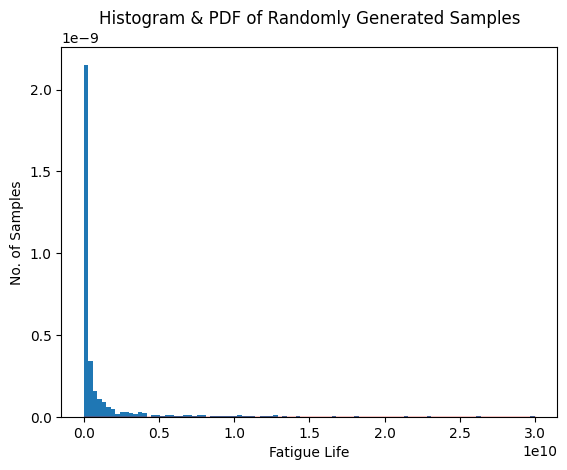

In [20]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x1)-mu)**2/(2*sigma**2))
       /(x1*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=1, color='r')
plt.axis('tight')
plt.show()

In [21]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 1045103802.5867825
The standard deviation of the fatigue life is 2711730154.2176924


## GEV, P vs sqrt(A)

- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

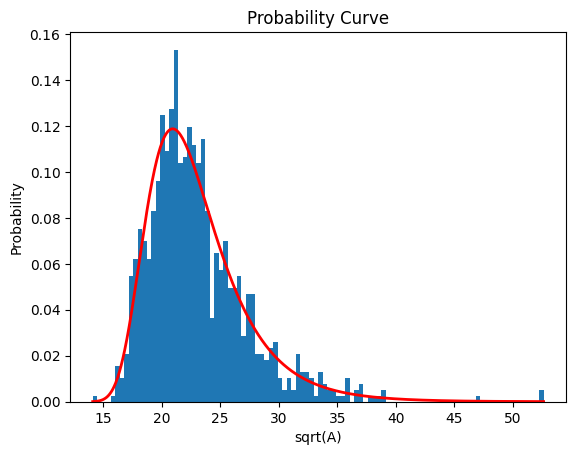

In [22]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density fxn
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

## S-N Curve

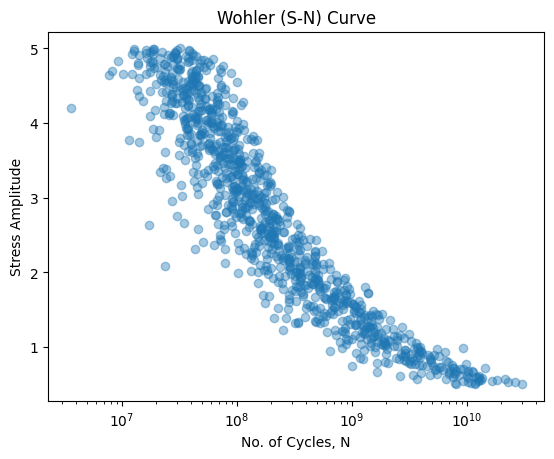

In [23]:
# data
x4 = lives
y4 = stress_norm

# scatter plot of stress vs fatigue life
plt.scatter(x4, y4, alpha=0.4)
plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress Amplitude')

plt.xscale('log')

plt.show()

### Confidence Intervals

In [24]:
logN = np.log10(lives)

# create bins for logN
bins = np.linspace(min(logN), max(logN), 20)

# calculate mean and std dev of stress values in each bin
stress_avg = []
stress_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logN >= bins[i]) & (logN < bins[i+1])
    stresses_in_bin = np.array(stress)[mask]

    if stresses_in_bin.size == 0:
        continue
    
    stress_avg.append(np.mean(np.array(stress, dtype=float)[mask]))
    stress_std.append(np.std(np.array(stress, dtype=float)[mask]))
    centers.append(0.5 * (bins[i] + bins[i+1]))

stress_avg = np.array(stress_avg)
stress_std = np.array(stress_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper = stress_avg + 1.96 * stress_std
lower = stress_avg - 1.96 * stress_std

upper = np.array(upper)
lower = np.array(lower)

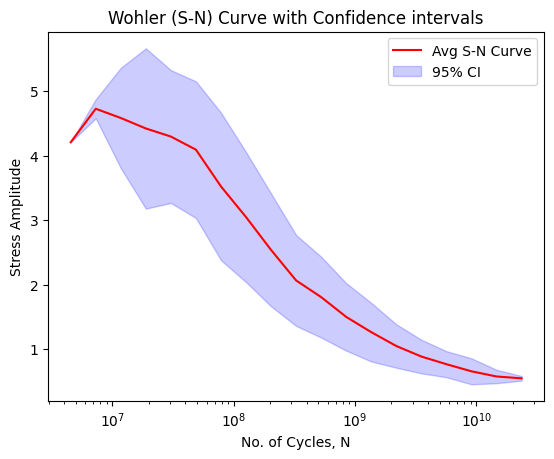

In [25]:
xvals = np.power(10, centers)

plt.plot(xvals, stress_avg, 'red', label='Avg S-N Curve')

plt.fill_between(xvals, lower, upper,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

plt.xscale('log')

# axis labels
plt.title('Wohler (S-N) Curve with Confidence intervals')
plt.xlabel('No. of Cycles, N')
plt.ylabel('Stress Amplitude')

plt.xscale('log')
plt.legend()
plt.show()

## Shiozawa Curve

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

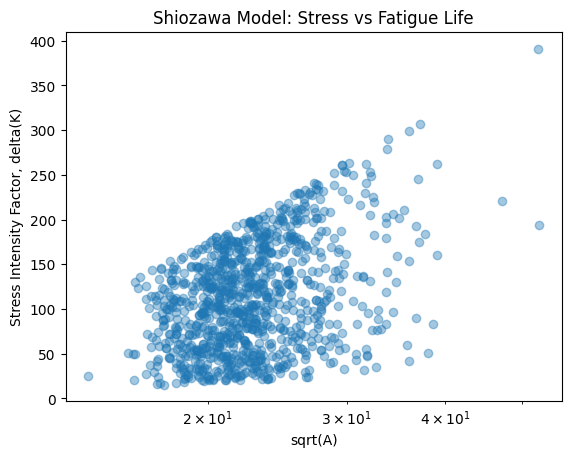

In [27]:
# scatter plot of delta(K) vs sqrt(A)
plt.scatter(M, K, alpha=0.4)
plt.xscale('log')

# axis labels
plt.title('Shiozawa Model: Stress vs Fatigue Life')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.xscale('log')

plt.show()

### Confidence Intervals

In [28]:
logM = np.log10(M)

# create bins for logM
bins = np.linspace(min(logM), max(logM), 20)

# calculate mean and std dev of stress values in each bin
K_avg = []
K_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logM >= bins[i]) & (logM < bins[i+1])
    Ks_in_bin = np.array(K)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    K_avg.append(np.mean(Ks_in_bin))
    K_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins[i] + bins[i+1]))

K_avg = np.array(K_avg)
K_std = np.array(K_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = K_avg + 1.96 * K_std
lower_K = K_avg - 1.96 * K_std

upper = np.array(upper_K)
lower = np.array(lower_K)

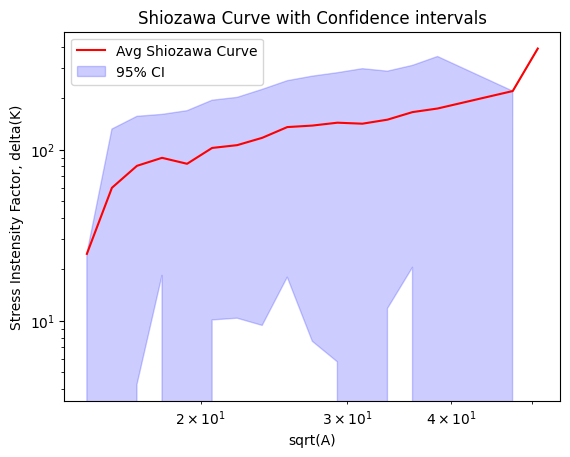

In [29]:
xvals1 = np.power(10, centers)

plt.plot(xvals1, K_avg, 'red', label='Avg Shiozawa Curve')

plt.fill_between(xvals1, lower_K, upper_K,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Curve with Confidence intervals')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Instensity Factor, delta(K)')

plt.legend()
plt.show()

In [30]:
# reliability curves